# Part 2: Implementation Tasks

In [16]:
import os
import torch
import pandas as pd
import numpy as np
import torchvision
import torch.nn as nn
import cv2
import matplotlib.pyplot as plt

# Task 3: Corner Detection

Question 1

In [24]:
img1 = cv2.imread('/content/drive/MyDrive/csc420/q4_1.jpg', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('/content/drive/MyDrive/csc420/q4_2.jpg', cv2.IMREAD_GRAYSCALE)

In [25]:
def second_moment_matrix(img, sigma=2):
    m, n = img.shape
    Ix = cv2.Sobel(img, cv2.CV_64F, 1, 0)
    Iy = cv2.Sobel(img, cv2.CV_64F, 0, 1)

    Ix2_blur = cv2.GaussianBlur(Ix ** 2, (9, 9), sigma)
    Iy2_blur = cv2.GaussianBlur(Iy ** 2, (9, 9), sigma)
    IxIy_blur = cv2.GaussianBlur(Ix * Iy, (9, 9), sigma)

    e = np.zeros((m, n, 2))
    for i in range(m):
        for j in range(n):
            e[i][j] = np.linalg.eigvals(np.array([[Ix2_blur[i][j], IxIy_blur[i][j]],
                                                  [IxIy_blur[i][j], Iy2_blur[i][j]]]))
    return e

In [26]:
e1 = second_moment_matrix(img1)
e2 = second_moment_matrix(img2)

In [27]:
print(e1.shape)
print(e2.shape)

(450, 800, 2)
(533, 800, 2)


Question 2

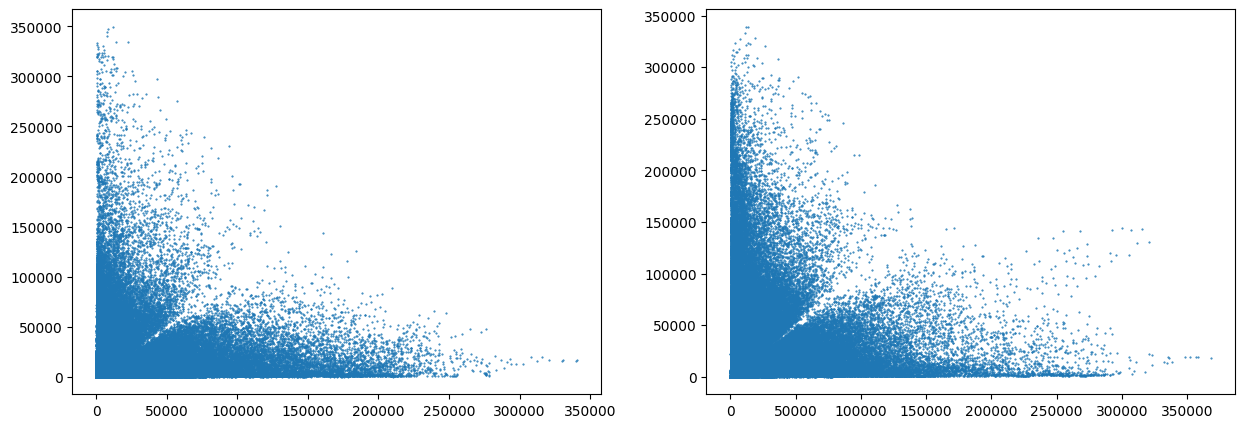

In [28]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
e1_x, e1_y = e1[:,:,0], e1[:,:,1]
ax[0].scatter(e1_x, e1_y, s=0.25)

e2_x, e2_y = e2[:,:,0], e2[:,:,1]
ax[1].scatter(e2_x, e2_y, s=0.25)

plt.show()

Question 3

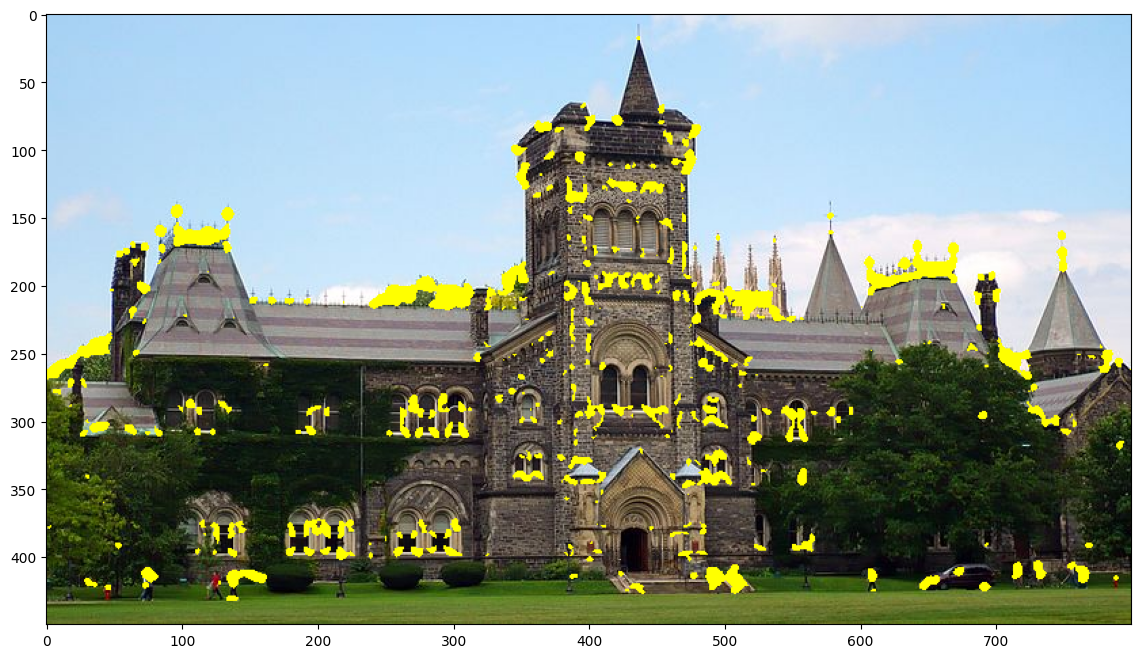

In [34]:
img1 = cv2.imread('/content/drive/MyDrive/csc420/q4_1.jpg')
img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)

threshold = 2e4
_min = np.minimum(e1_x, e1_y)
img1[_min > threshold] = [255, 255, 0]
plt.figure(figsize=(14,12))
plt.imshow(img1)

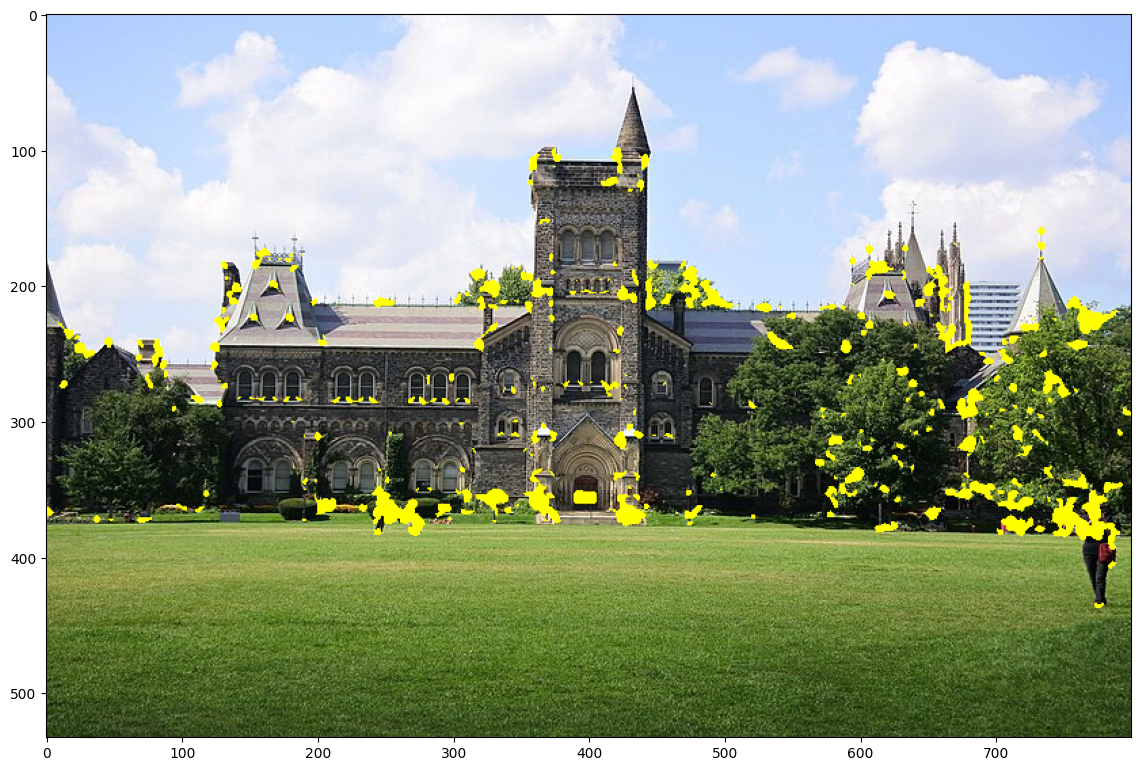

In [37]:
img2 = cv2.imread('/content/drive/MyDrive/csc420/q4_2.jpg')
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

threshold = 3e4
_min = np.minimum(e2_x, e2_y)
img2[_min > threshold] = [255, 255, 0]
plt.figure(figsize=(14,12))
plt.imshow(img2)

Question 4

In [39]:
img1 = cv2.imread('/content/drive/MyDrive/csc420/q4_1.jpg', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('/content/drive/MyDrive/csc420/q4_2.jpg', cv2.IMREAD_GRAYSCALE)

In [40]:
e1 = second_moment_matrix(img1, sigma=10)
e2 = second_moment_matrix(img2, sigma=10)

In [41]:
e1_x, e1_y = e1[:,:,0], e1[:,:,1]
e2_x, e2_y = e2[:,:,0], e2[:,:,1]

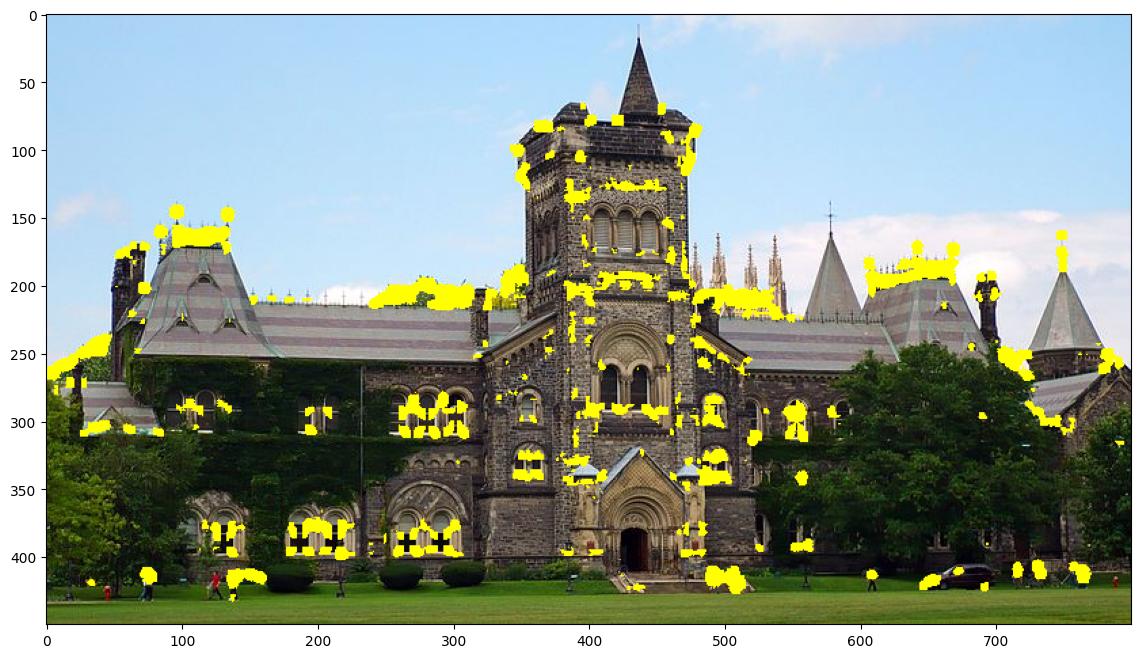

In [42]:
img1 = cv2.imread('/content/drive/MyDrive/csc420/q4_1.jpg')
img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)

threshold = 2e4
_min = np.minimum(e1_x, e1_y)
img1[_min > threshold] = [255, 255, 0]
plt.figure(figsize=(14,12))
plt.imshow(img1)

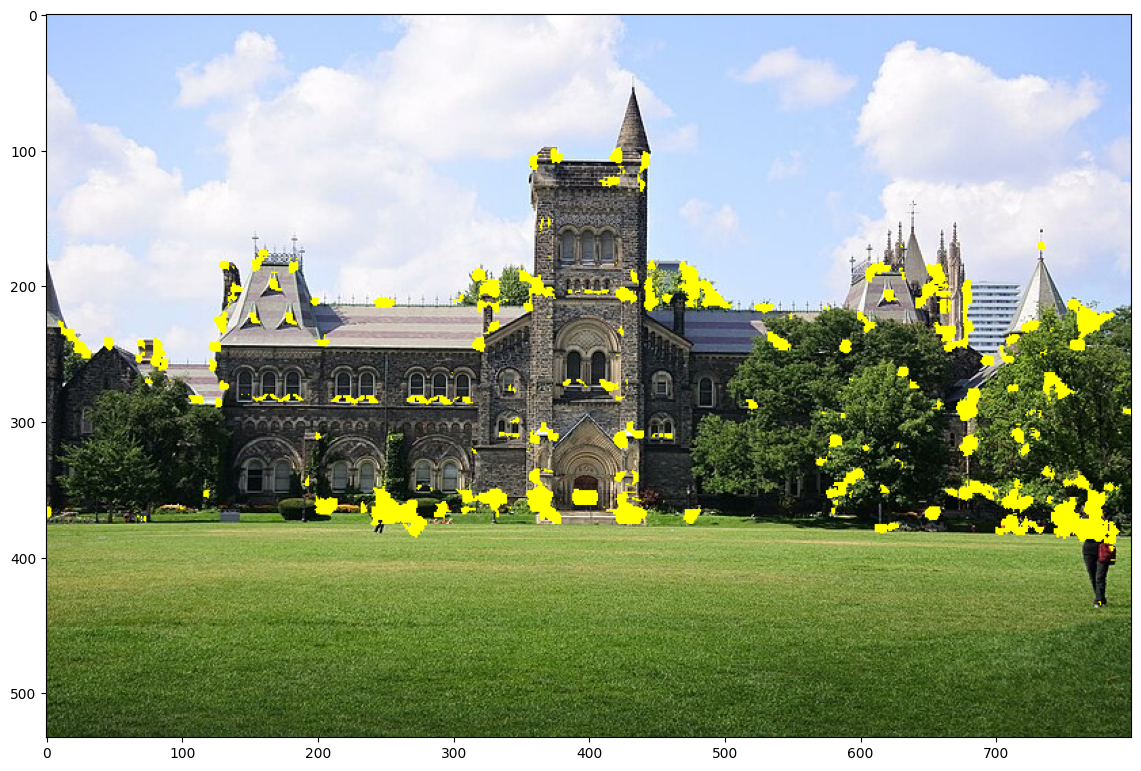

In [43]:
img2 = cv2.imread('/content/drive/MyDrive/csc420/q4_2.jpg')
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

threshold = 3e4
_min = np.minimum(e2_x, e2_y)
img2[_min > threshold] = [255, 255, 0]
plt.figure(figsize=(14,12))
plt.imshow(img2)

Increasing the sigma value in the Gaussian kernel for corner detection influenced each of the images by reducing the number of detected corners, especially in areas with finer details.

Image 1: With the higher sigma, the corner detection focused more on larger architectural features, like the main corners and edges of the building, rather than detecting every small texture or detail.

Image 2: Similarly, in Image 2, the increased sigma reduced the number of detected corners in the lawn and trees, where there might have been more texture-based detections with a smaller sigma. The detection primarily highlighted larger structures, such as the main edges of the towers and building outline, while filtering out less significant features in the scene.

Overall, this choice of a larger sigma reduced the sensitivity to small, local variations, focusing the corner detection on more prominent, structural elements in both images and filtering out finer details that might contribute to noise in corner detection.






